In [1]:
cuda:1

In [20]:
# requires: tensorflow >= 2.6, numpy, matplotlib, opencv-python (cv2)
import os
import time
import glob
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger
import matplotlib.pyplot as plt
import cv2

# ----------------------
# USER: set paths below
# ----------------------
DATA_ROOT = "./"  
# expected structure:
# DATA_ROOT/images/*.png    # original MR images (512x512)
# DATA_ROOT/masks/*.png     # corresponding binary masks (same filenames)
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ----------------------
# HYPERPARAMETERS
# ----------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-4
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# For P6 specifics
BASE_CHANNELS = 32
KERNEL_SIZE = (5, 5)
DROPOUT_RATE = 0.3
ACTIVATION_LAYER = lambda: layers.LeakyReLU(alpha=0.1)


# ----------------------
# Utility functions
# ----------------------
def list_image_mask_pairs(images_dir, masks_dir):
    # assumes same filenames in both dirs
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.png")))
    mask_files = [os.path.join(masks_dir, os.path.basename(p)) for p in image_files]
    # filter out missing
    pairs = [(i, m) for i, m in zip(image_files, mask_files) if os.path.exists(m)]
    return pairs

def read_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, IMG_SIZE)
    return img

def read_mask(path):
    m = tf.io.read_file(path)
    m = tf.image.decode_png(m, channels=1)  # single channel
    # convert to 0/1
    m = tf.where(m > 128, 1.0, 0.0)
    m = tf.image.resize(m, IMG_SIZE, method='nearest')
    return tf.cast(m, tf.float32)

def preprocess(image_path, mask_path, augment=False):
    img = read_image(image_path)
    mask = read_mask(mask_path)
    if augment:
        # simple augmentations
        if tf.random.uniform(()) > 0.5:
            img = tf.image.flip_left_right(img)
            mask = tf.image.flip_left_right(mask)
        if tf.random.uniform(()) > 0.5:
            img = tf.image.random_brightness(img, 0.1)
    return img, mask

def make_dataset(pairs, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    image_paths = [p for p, _ in pairs]
    mask_paths = [m for _, m in pairs]
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(pairs), seed=RANDOM_SEED)
    ds = ds.map(lambda x, y: tf.py_function(preprocess, [x, y, augment], [tf.float32, tf.float32]),
                num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (tf.reshape(x, [*IMG_SIZE, 3]), tf.reshape(y, [*IMG_SIZE, 1])),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# ----------------------
# Model: Modified U-Net P6
# ----------------------
def conv_block(x, filters, kernel_size=KERNEL_SIZE, dropout=None):
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = ACTIVATION_LAYER()(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = ACTIVATION_LAYER()(x)
    if dropout:
        x = layers.Dropout(dropout)(x)
    return x

def encoder_block(x, filters, kernel_size=KERNEL_SIZE, dropout=None):
    c = conv_block(x, filters, kernel_size, dropout)
    p = layers.AveragePooling2D(pool_size=(2,2))(c)   # average pooling per paper
    return c, p

def decoder_block(x, skip, filters, kernel_size=KERNEL_SIZE):
    x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, kernel_size)
    return x

def build_unet_p6(input_shape=(*IMG_SIZE, 3), base_filters=BASE_CHANNELS, dropout=DROPOUT_RATE):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, base_filters, KERNEL_SIZE, dropout)            # 32
    c2, p2 = encoder_block(p1, base_filters*2, KERNEL_SIZE, dropout)             # 64
    c3, p3 = encoder_block(p2, base_filters*4, KERNEL_SIZE, dropout)             # 128
    c4, p4 = encoder_block(p3, base_filters*8, KERNEL_SIZE, dropout)             # 256

    # Bridge
    b = conv_block(p4, base_filters*16, KERNEL_SIZE, dropout)

    # Decoder
    d4 = decoder_block(b, c4, base_filters*8, KERNEL_SIZE)
    d3 = decoder_block(d4, c3, base_filters*4, KERNEL_SIZE)
    d2 = decoder_block(d3, c2, base_filters*2, KERNEL_SIZE)
    d1 = decoder_block(d2, c1, base_filters, KERNEL_SIZE)

    # Output
    outputs = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid')(d1)  # binary segmentation
    model = models.Model(inputs, outputs, name="UNet_P6")
    return model

# ----------------------
# Losses & Metrics
# ----------------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred, bce_weight=0.5):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce_weight * bce + (1.0 - bce_weight) * dice_loss(y_true, y_pred)

# IoU metric (per-batch)
def iou_metric(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred_thresh = tf.cast(y_pred > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_thresh)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_thresh) - intersection
    return (intersection + smooth) / (union + smooth)

# global accuracy: fraction of correctly classified pixels
def global_accuracy(y_true, y_pred, threshold=0.5):
    y_pred_thresh = tf.cast(y_pred > threshold, tf.float32)
    correct = tf.cast(tf.equal(y_true, y_pred_thresh), tf.float32)
    return tf.reduce_mean(correct)


# ----------------------
# Load & split dataset
# ----------------------
images_dir = os.path.join(DATA_ROOT, "images")
masks_dir  = os.path.join(DATA_ROOT, "masks")
pairs_all = list_image_mask_pairs(images_dir, masks_dir)
random.Random(RANDOM_SEED).shuffle(pairs_all)

n_total = len(pairs_all)
n_train = int(0.70 * n_total)
n_val = int(0.10 * n_total)
n_test = n_total - n_train - n_val

train_pairs = pairs_all[:n_train]
val_pairs   = pairs_all[n_train:n_train + n_val]
test_pairs  = pairs_all[n_train + n_val:]

print(f"Total: {n_total}  train: {len(train_pairs)}  val: {len(val_pairs)}  test: {len(test_pairs)}")

train_ds = make_dataset(train_pairs, BATCH_SIZE, shuffle=True, augment=True)
val_ds   = make_dataset(val_pairs, BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_dataset(test_pairs, BATCH_SIZE, shuffle=False, augment=False)

# ----------------------
# Build and compile model
# ----------------------
model = build_unet_p6()
model.summary()   # show architecture and parameter count (~5.5M expected)

optimizer = tf.keras.optimizers.RMSprop(learning_rate=LR)  # paper uses RMSProp for P6

model.compile(optimizer=optimizer,
              loss=lambda y_true, y_pred: bce_dice_loss(y_true, y_pred, bce_weight=0.4),
              metrics=[dice_coef, iou_metric, global_accuracy])

# ----------------------
# Callbacks
# ----------------------
checkpoint_path = os.path.join(CHECKPOINT_DIR, "unet_p6_best.h5")
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_dice_coef', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1, min_lr=1e-7),
    EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, verbose=1, restore_best_weights=True),
    CSVLogger(os.path.join(CHECKPOINT_DIR, 'training_log.csv'))
]

# ----------------------
# Train
# ----------------------
start = time.time()
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=2
)
end = time.time()
elapsed_min = (end - start) / 60.0
print(f"Training finished in {elapsed_min:.2f} minutes")

# ----------------------
# Evaluate on test set
# ----------------------
print("Evaluating on test set...")
results = model.evaluate(test_ds, verbose=2)
print("Test results (loss, dice, iou, global_acc):", results)

# ----------------------
# Inference helper
# ----------------------
def predict_and_show(model, image_path, mask_path=None, threshold=0.5):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, IMG_SIZE)
    img_norm = img_resized.astype('float32') / 255.0
    pred = model.predict(np.expand_dims(img_norm, 0))[0,...,0]
    pred_bin = (pred > threshold).astype(np.uint8)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img_resized)
    plt.axis('off')

    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, IMG_SIZE)
        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
    else:
        plt.subplot(1,3,2); plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred, cmap='jet')
    plt.contour(pred_bin, colors='white', linewidths=0.5)
    plt.axis('off')
    plt.show()

# Example usage:
# predict_and_show(model, "/path/to/some/image.png", "/path/to/some/mask.png")


Total: 3064  train: 2144  val: 306  test: 614
Model: "UNet_P6"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d_76 (Conv2D)          (None, 224, 224, 32)         2400      ['input_5[0][0]']             
                                                                                                  
 batch_normalization_72 (Ba  (None, 224, 224, 32)         128       ['conv2d_76[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 leaky_re_lu_72 (LeakyReLU)  (None, 224, 224, 

/nfsshare/users/kamali/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


67/67 - 81s - loss: 0.7746 - dice_coef: 0.0379 - iou_metric: 0.0281 - global_accuracy: 0.8517 - val_loss: 0.7982 - val_dice_coef: 0.0287 - val_iou_metric: 3.5868e-11 - val_global_accuracy: 0.9808 - lr: 1.0000e-04 - 81s/epoch - 1s/step
Epoch 2/100

Epoch 2: val_dice_coef did not improve from 0.02872
67/67 - 72s - loss: 0.6996 - dice_coef: 0.0416 - iou_metric: 0.0455 - global_accuracy: 0.9780 - val_loss: 0.7882 - val_dice_coef: 0.0251 - val_iou_metric: 1.2412e-05 - val_global_accuracy: 0.8649 - lr: 1.0000e-04 - 72s/epoch - 1s/step
Epoch 3/100

Epoch 3: val_dice_coef improved from 0.02872 to 0.03151, saving model to ./checkpoints/unet_p6_best.h5
67/67 - 72s - loss: 0.6779 - dice_coef: 0.0469 - iou_metric: 0.0770 - global_accuracy: 0.9764 - val_loss: 0.7301 - val_dice_coef: 0.0315 - val_iou_metric: 7.1018e-04 - val_global_accuracy: 0.9769 - lr: 1.0000e-04 - 72s/epoch - 1s/step
Epoch 4/100

Epoch 4: val_dice_coef improved from 0.03151 to 0.04288, saving model to ./checkpoints/unet_p6_best.h

/nfsshare/users/kamali/.conda/envs/myenv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_491896/1172167014.py:21: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
/tmp/ipykernel_491896/1172167014.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),


🔄 Starting preprocessing visualization...
📁 Image directory: images
📁 Mask directory: masks
🖼️  Image size: (256, 256)
📊 Visualizing 3 random samples from dataset...


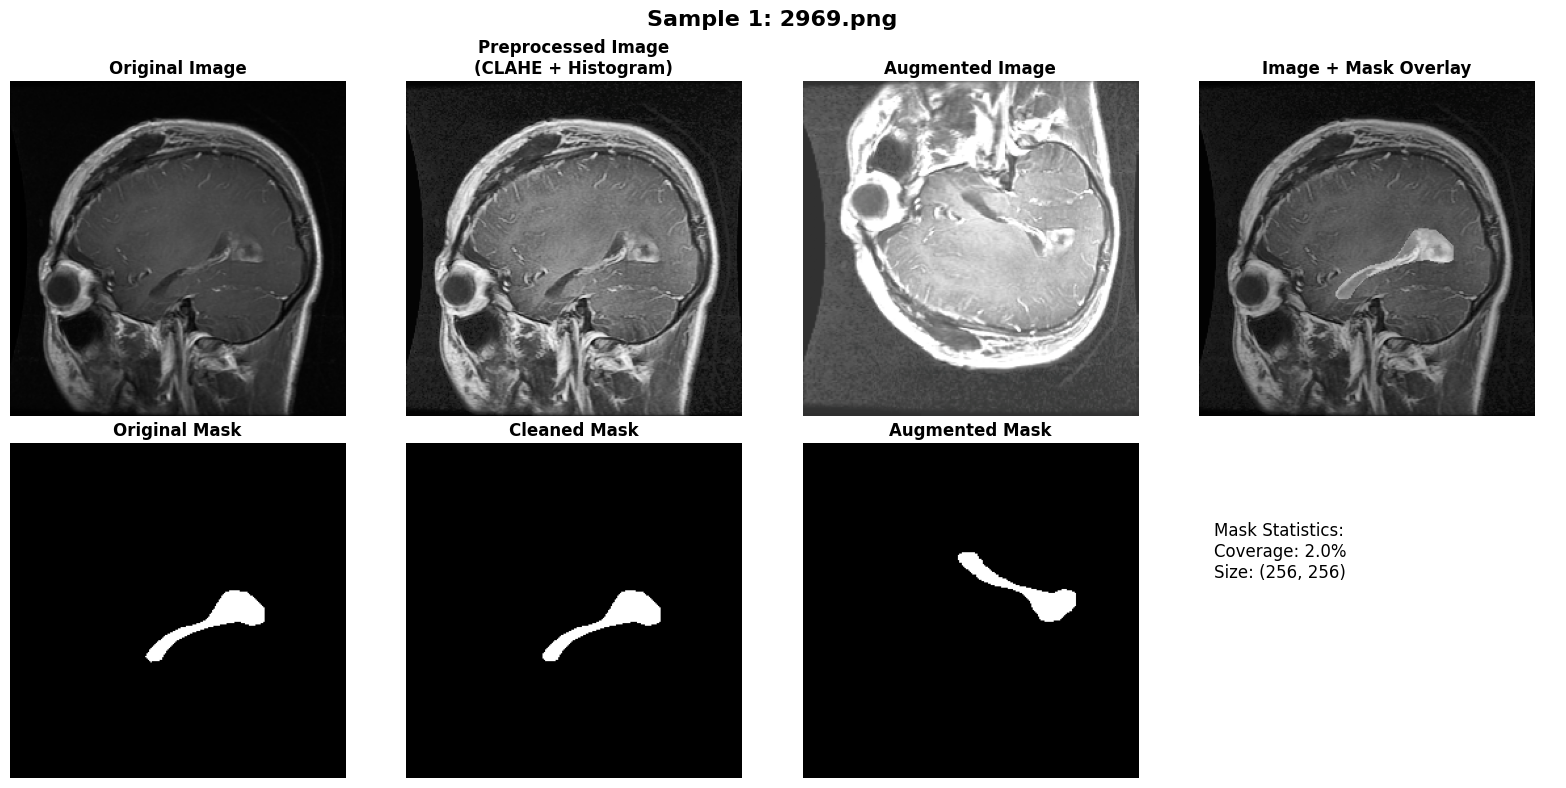

📐 Image size: (256, 256, 3)
🎯 Mask coverage: 2.0%
--------------------------------------------------


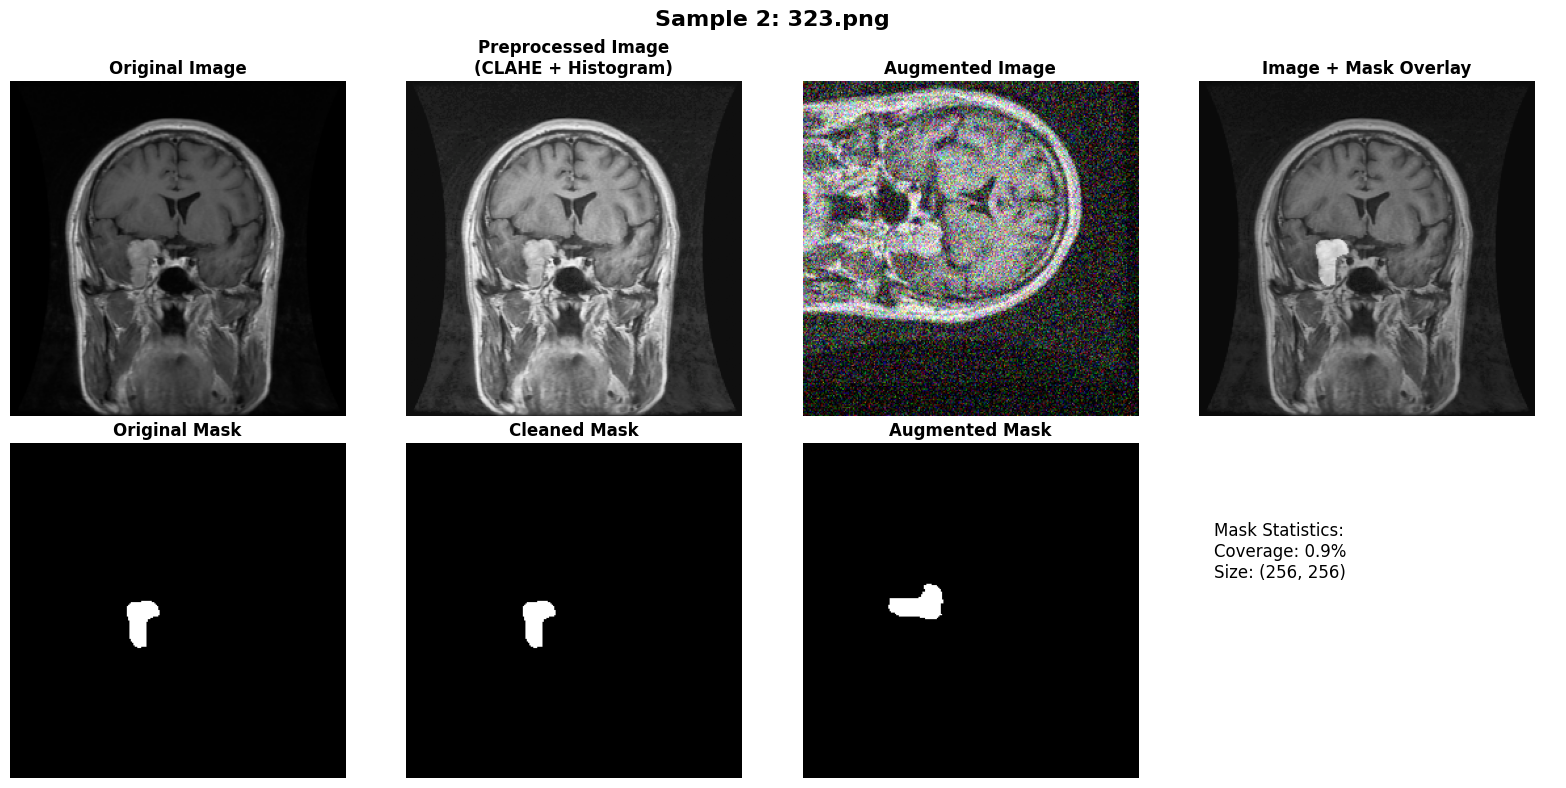

📐 Image size: (256, 256, 3)
🎯 Mask coverage: 0.9%
--------------------------------------------------


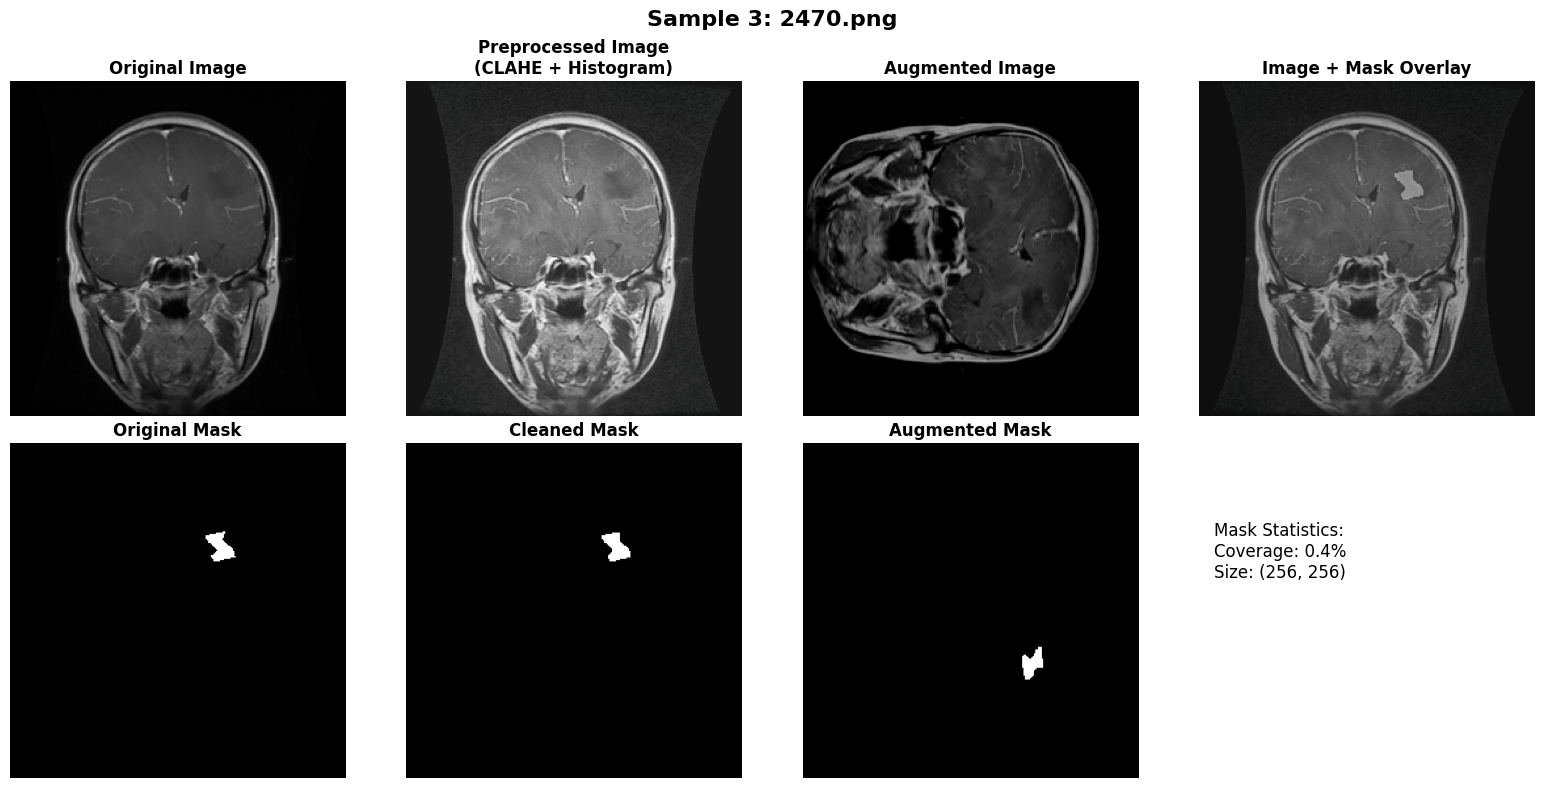

📐 Image size: (256, 256, 3)
🎯 Mask coverage: 0.4%
--------------------------------------------------
✅ Preprocessing visualization completed!


In [1]:
# =============================================
# PREPROCESSING VISUALIZATION ONLY
# =============================================
import os, cv2
import numpy as np
from skimage import morphology, exposure
import albumentations as A
import matplotlib.pyplot as plt

# Configuration
IMAGE_DIR = "images"
MASK_DIR = "masks"
IMG_SIZE = (256, 256)

# ---------------- AUGMENTATION PIPELINE ----------------
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.2, rotate_limit=45, p=0.8),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
])

# ---------------- PREPROCESSING FUNCTIONS ----------------
def _apply_advanced_clahe(img_uint8):
    """Multi-scale CLAHE for better contrast"""
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
   
    clahe1 = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    clahe2 = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(16,16))
   
    l1 = clahe1.apply(l)
    l2 = clahe2.apply(l)
   
    l_enhanced = cv2.addWeighted(l1, 0.6, l2, 0.4, 0)
    lab = cv2.merge((l_enhanced, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def _apply_histogram_equalization(img_uint8):
    """Apply histogram equalization to each channel"""
    img_enhanced = np.zeros_like(img_uint8)
    for i in range(3):
        img_enhanced[:,:,i] = exposure.equalize_hist(img_uint8[:,:,i]) * 255
    return img_enhanced.astype(np.uint8)

def preprocess_and_augment(img_path, mask_path, augment=True):
    try:
        img_bgr = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
       
        if img_bgr is None or mask is None:
            return None, None
           
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_CUBIC)
        mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

        # Mask cleaning
        if np.max(mask) > 1:
            mask_bool = mask > 127
        else:
            mask_bool = mask > 0.5
           
        mask_bool = morphology.remove_small_objects(mask_bool, min_size=150)
        mask_bool = morphology.remove_small_holes(mask_bool, area_threshold=150)
       
        kernel = np.ones((3,3), np.uint8)
        mask_bool = morphology.binary_closing(mask_bool, kernel)
        mask_bool = morphology.binary_opening(mask_bool, kernel)
       
        mask_uint8 = (mask_bool.astype(np.uint8) * 255)

        # Image enhancement
        img_clahe = _apply_advanced_clahe(img_rgb)
        img_hist = _apply_histogram_equalization(img_rgb)
        img_enhanced = cv2.addWeighted(img_clahe, 0.7, img_hist, 0.3, 0)

        if augment:
            try:
                aug = aug_pipeline(image=img_enhanced, mask=mask_uint8)
                img_enhanced, mask_uint8 = aug['image'], aug['mask']
            except:
                pass

        img_out = img_enhanced.astype(np.float32) / 255.0
        mask_out = np.expand_dims((mask_uint8 > 127).astype(np.float32), -1)
        return img_out, mask_out
       
    except Exception as e:
        return None, None

# ---------------- VISUALIZATION ----------------
def visualize_preprocessing_examples(n=3):
    """Visualize preprocessing steps for random samples"""
    # Get image files
    img_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]
    mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]
   
    common_files = sorted(list(set(img_files) & set(mask_files)))
   
    if not common_files:
        print("❌ No common image-mask pairs found!")
        return
   
    n = min(n, len(common_files))
    selected_files = np.random.choice(common_files, n, replace=False)
   
    print(f"📊 Visualizing {n} random samples from dataset...")
   
    for i, filename in enumerate(selected_files):
        img_path = os.path.join(IMAGE_DIR, filename)
        mask_path = os.path.join(MASK_DIR, filename)
       
        # Load original
        orig_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        orig_img = cv2.resize(orig_img, IMG_SIZE)
        orig_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        orig_mask = cv2.resize(orig_mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
       
        # Get processed versions
        prep_img, prep_mask = preprocess_and_augment(img_path, mask_path, augment=False)
        aug_img, aug_mask = preprocess_and_augment(img_path, mask_path, augment=True)
       
        # Create visualization
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f'Sample {i+1}: {filename}', fontsize=16, fontweight='bold')
       
        # Original
        axes[0,0].imshow(orig_img)
        axes[0,0].set_title('Original Image', fontweight='bold')
        axes[0,0].axis('off')
       
        axes[1,0].imshow(orig_mask, cmap='gray')
        axes[1,0].set_title('Original Mask', fontweight='bold')
        axes[1,0].axis('off')
       
        # Preprocessed
        if prep_img is not None:
            axes[0,1].imshow(np.clip(prep_img, 0, 1))
            axes[0,1].set_title('Preprocessed Image\n(CLAHE + Histogram)', fontweight='bold')
            axes[0,1].axis('off')
           
            axes[1,1].imshow(prep_mask[:,:,0], cmap='gray')
            axes[1,1].set_title('Cleaned Mask', fontweight='bold')
            axes[1,1].axis('off')
       
        # Augmented
        if aug_img is not None:
            axes[0,2].imshow(np.clip(aug_img, 0, 1))
            axes[0,2].set_title('Augmented Image', fontweight='bold')
            axes[0,2].axis('off')
           
            axes[1,2].imshow(aug_mask[:,:,0], cmap='gray')
            axes[1,2].set_title('Augmented Mask', fontweight='bold')
            axes[1,2].axis('off')
       
        # Mask overlay
        if prep_img is not None and prep_mask is not None:
            overlay = np.clip(prep_img, 0, 1).copy()
            mask_rgb = np.stack([prep_mask[:,:,0]]*3, axis=-1)
            overlay = cv2.addWeighted(overlay, 0.7, mask_rgb, 0.3, 0)
            axes[0,3].imshow(overlay)
            axes[0,3].set_title('Image + Mask Overlay', fontweight='bold')
            axes[0,3].axis('off')
       
        # Stats
        if orig_mask is not None:
            mask_coverage = np.sum(orig_mask > 127) / (orig_mask.shape[0] * orig_mask.shape[1]) * 100
            axes[1,3].text(0.1, 0.6, f'Mask Statistics:\nCoverage: {mask_coverage:.1f}%\nSize: {orig_mask.shape}',
                          fontsize=12, transform=axes[1,3].transAxes)
            axes[1,3].axis('off')
       
        plt.tight_layout()
        plt.show()
       
        # Print additional info
        print(f"📐 Image size: {orig_img.shape}")
        if orig_mask is not None:
            print(f"🎯 Mask coverage: {mask_coverage:.1f}%")
        print("-" * 50)

# ---------------- RUN VISUALIZATION ----------------
print("🔄 Starting preprocessing visualization...")
print(f"📁 Image directory: {IMAGE_DIR}")
print(f"📁 Mask directory: {MASK_DIR}")
print(f"🖼️  Image size: {IMG_SIZE}")

# Run visualization
visualize_preprocessing_examples(n=3)

print("✅ Preprocessing visualization completed!")

📦 Rebuilding model and loading weights...
✅ Model architecture rebuilt and weights loaded!

🧩 FIGURE 8 – Single Image Visualization


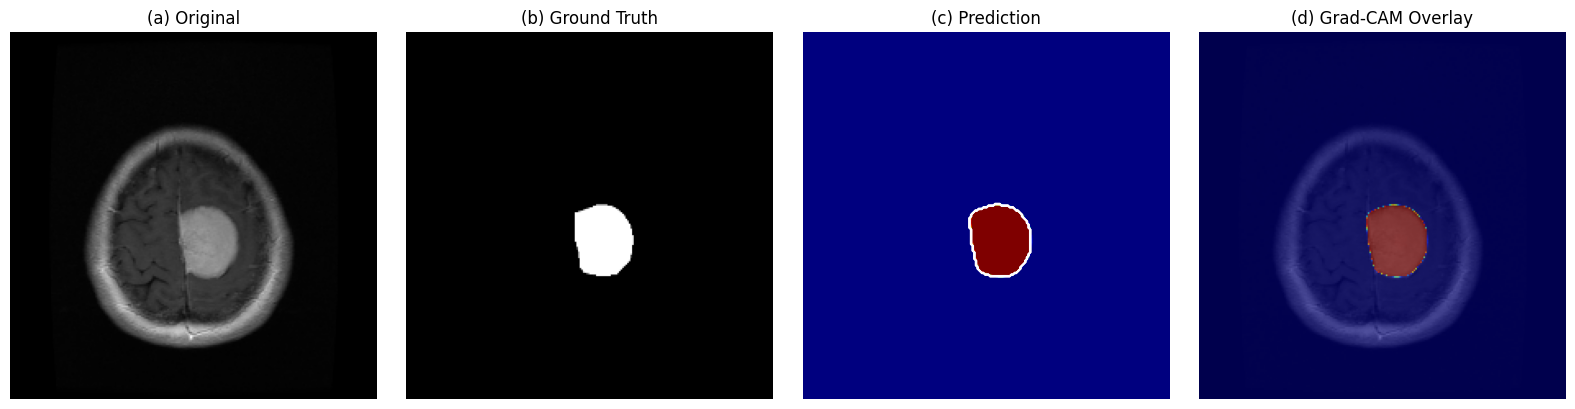


🔥 FIGURE 7 – Grad-CAM Grid Visualization


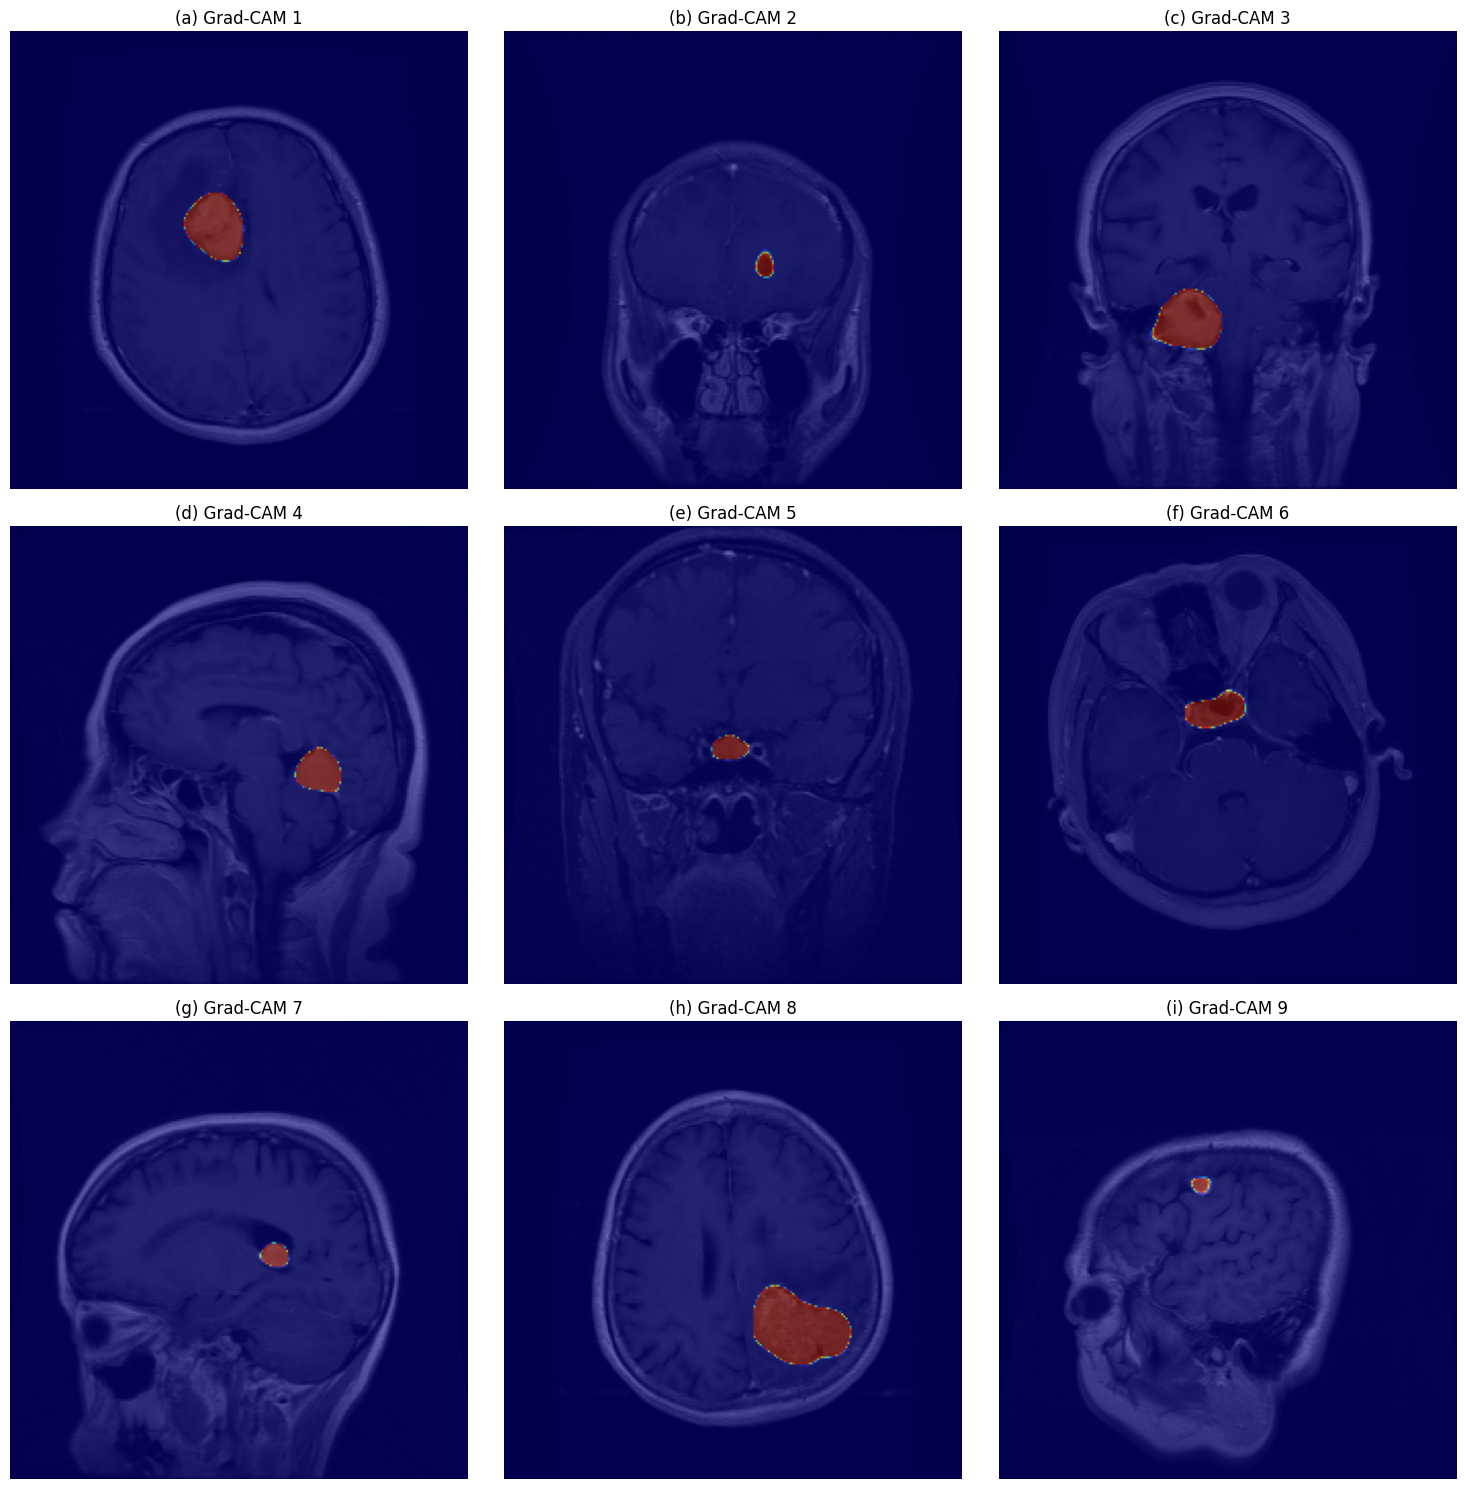

In [7]:
# =====================================================
# 🎯 FIXED: TEST + FIGURE 7 & 8 VISUALIZATION (LOAD WEIGHTS ONLY)
# =====================================================
import os, cv2, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.models import Model

# =====================================================
# 1️⃣ METRICS
# =====================================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f, y_pred_f = K.flatten(y_true), K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred): return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.4 * bce + 0.6 * dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred = tf.cast(y_pred > threshold, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return (inter + smooth) / (union + smooth)

def global_accuracy(y_true, y_pred, threshold=0.5):
    y_pred = tf.cast(y_pred > threshold, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

# =====================================================
# 2️⃣ REBUILD UNET_P6 ARCHITECTURE
# =====================================================
def build_unet_p6(input_shape=(224, 224, 3), base_filters=32, dropout=0.3):
    def conv_block(x, f, k=(5,5), d=None):
        x = layers.Conv2D(f, k, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(alpha=0.1)(x)
        x = layers.Conv2D(f, k, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(alpha=0.1)(x)
        if d: x = layers.Dropout(d)(x)
        return x
    def enc(x, f, k=(5,5), d=None):
        c = conv_block(x, f, k, d); p = layers.AveragePooling2D((2,2))(c)
        return c, p
    def dec(x, s, f, k=(5,5)):
        x = layers.Conv2DTranspose(f, (2,2), strides=(2,2), padding='same')(x)
        x = layers.Concatenate()([x, s])
        x = conv_block(x, f, k)
        return x
    inp = layers.Input(shape=input_shape)
    c1, p1 = enc(inp, base_filters, (5,5), dropout)
    c2, p2 = enc(p1, base_filters*2, (5,5), dropout)
    c3, p3 = enc(p2, base_filters*4, (5,5), dropout)
    c4, p4 = enc(p3, base_filters*8, (5,5), dropout)
    b = conv_block(p4, base_filters*16, (5,5), dropout)
    d4 = dec(b, c4, base_filters*8, (5,5))
    d3 = dec(d4, c3, base_filters*4, (5,5))
    d2 = dec(d3, c2, base_filters*2, (5,5))
    d1 = dec(d2, c1, base_filters, (5,5))
    out = layers.Conv2D(1, (1,1), activation='sigmoid')(d1)
    return models.Model(inp, out, name="UNet_P6")

# =====================================================
# 3️⃣ LOAD WEIGHTS
# =====================================================
model_path = "./checkpoints/unet_p6_best.h5"
print("📦 Rebuilding model and loading weights...")
model = build_unet_p6()
model.compile(optimizer='adam', loss=bce_dice_loss, metrics=[dice_coef, iou_metric])
model.load_weights(model_path)
print("✅ Model architecture rebuilt and weights loaded!")

# =====================================================
# 4️⃣ GRAD-CAM UTILITIES
# =====================================================
def get_grad_cam(model, img_array, layer_name=None):
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break
    grad_model = Model(inputs=model.inputs,
                       outputs=[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_array)
        loss = pred[:, :, :, 0]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_out), axis=-1)
    cam = tf.maximum(cam, 0)
    cam = cam[0].numpy()
    return cam / (np.max(cam) + 1e-8)

def overlay_heatmap(heatmap, image, alpha=0.6, colormap=cv2.COLORMAP_JET):
    heatmap = np.clip(np.nan_to_num(heatmap), 0, 1)
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap)
    if heatmap_uint8.ndim == 3 and heatmap_uint8.shape[-1] == 1:
        heatmap_uint8 = heatmap_uint8[:, :, 0]
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(image, 1 - alpha, heatmap_color, alpha, 0)

# =====================================================
# 5️⃣ FIGURE 8 STYLE (SINGLE IMAGE)
# =====================================================
def test_single_image(model, image_path, mask_path=None):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_norm = img_resized.astype('float32') / 255.0
    pred = model.predict(np.expand_dims(img_norm, 0), verbose=0)[0, ..., 0]
    pred_bin = (pred > 0.5).astype(np.uint8)
    mask_resized = None
    if mask_path and os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (224, 224))
    heatmap = get_grad_cam(model, np.expand_dims(img_norm, 0))
    gradcam_overlay = overlay_heatmap(heatmap, img_resized)
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1); plt.imshow(img_resized); plt.title("(a) Original"); plt.axis("off")
    plt.subplot(1, 4, 2)
    if mask_resized is not None: plt.imshow(mask_resized, cmap="gray")
    plt.title("(b) Ground Truth"); plt.axis("off")
    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="jet", vmin=0, vmax=1)
    plt.contour(pred_bin, colors='white', linewidths=0.8)
    plt.title("(c) Prediction"); plt.axis("off")
    plt.subplot(1, 4, 4)
    plt.imshow(gradcam_overlay); plt.title("(d) Grad-CAM Overlay"); plt.axis("off")
    plt.tight_layout(); plt.show()

# =====================================================
# 6️⃣ FIGURE 7 STYLE (MULTI IMAGE GRID)
# =====================================================
def figure7_visualization(model, images_dir="./images", num_samples=9):
    files = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(".png")]
    selected = np.random.choice(len(files), min(num_samples, len(files)), replace=False)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15)); axes = axes.ravel()
    for i, idx in enumerate(selected):
        img = cv2.imread(files[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        img_norm = img_resized.astype('float32') / 255.0
        heatmap = get_grad_cam(model, np.expand_dims(img_norm, 0))
        overlay = overlay_heatmap(heatmap, img_resized)
        axes[i].imshow(overlay)
        axes[i].set_title(f"({chr(97+i)}) Grad-CAM {i+1}")
        axes[i].axis("off")
    plt.tight_layout(); plt.show()

# =====================================================
# 7️⃣ RUN BOTH VISUALIZATIONS
# =====================================================
image_path = "./images/14.png"   # change path as needed
mask_path  = "./masks/14.png"    # change path as needed

print("\n🧩 FIGURE 8 – Single Image Visualization")
test_single_image(model, image_path, mask_path)

print("\n🔥 FIGURE 7 – Grad-CAM Grid Visualization")
figure7_visualization(model)
